In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast

In [16]:
df_raw = pd.read_csv("tweets.csv")
df_matched = pd.read_csv("tweets_matched.csv")
df_dict = pd.read_csv("company_dict_10_industries.csv")

## 1-descriptive time distribution analysis（EST）

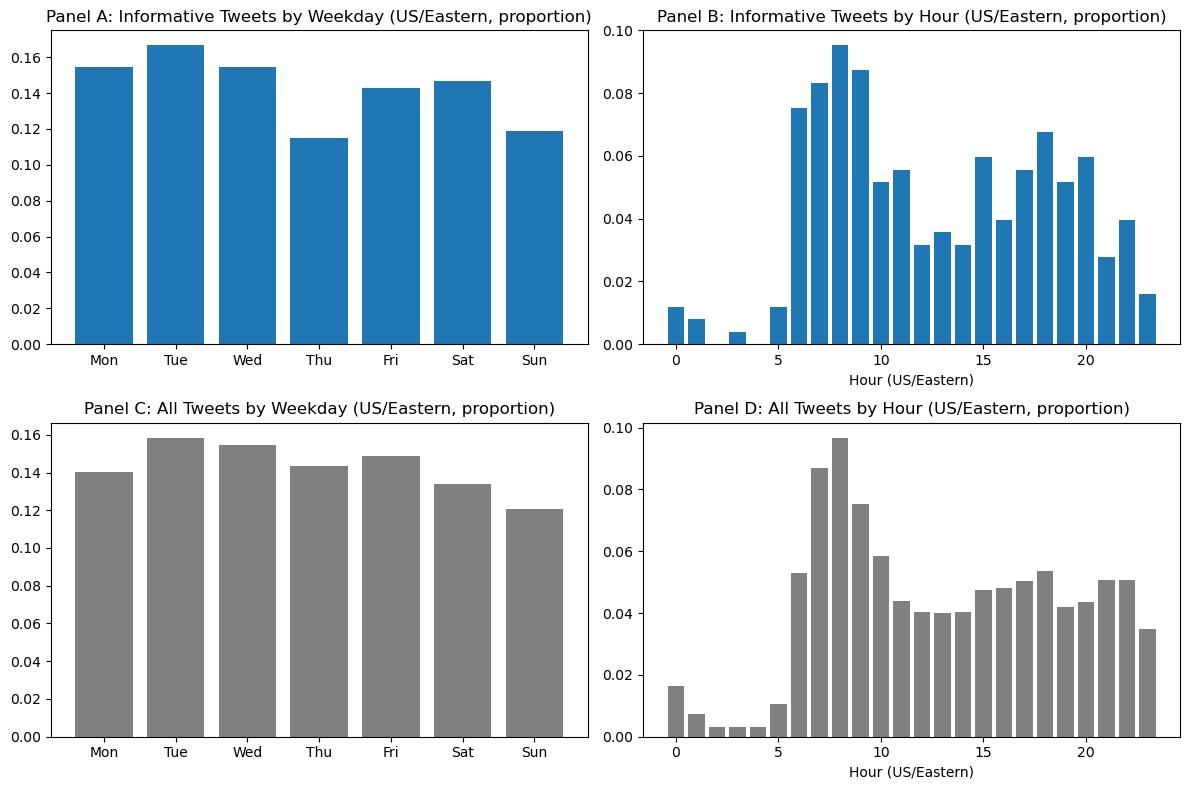

=== ALL ===
Peak EST hour: 8 Count: 1390 Proportion: 0.0967

=== INFORMATIVE ===
Peak EST hour: 8 Count: 24 Proportion: 0.0952


In [17]:

# ===============================
# 1️⃣  Timezone handling
# ===============================

#  UTC
df_matched['event_minute'] = pd.to_datetime(df_matched['event_minute'], utc=True)

#  US/Eastern
df_matched['event_minute_est'] = df_matched['event_minute'].dt.tz_convert('US/Eastern')

#  weekday 和 hour
df_matched['weekday_est'] = df_matched['event_minute_est'].dt.dayofweek  # 0=Mon
df_matched['hour_est'] = df_matched['event_minute_est'].dt.hour          # 0-23


# ===============================
# 2️⃣  Informative flag
# ===============================

if 'is_informative' in df_matched.columns:
    df_matched['is_informative_flag'] = (
        df_matched['is_informative']
        .astype(str)
        .str.lower()
        .isin(['1','true','t','yes','y'])
        .astype(int)
    )
else:
    df_matched['is_informative_flag'] = (
        df_matched['matched_tickers']
        .astype(str)
        .str.contains(r'[A-Za-z0-9]', na=False)
        .astype(int)
    )

df_info = df_matched[df_matched['is_informative_flag'] == 1].copy()
df_all = df_matched.copy()


# ===============================
# 3️⃣  Count distributions
# ===============================

# Weekday
info_weekday = df_info['weekday_est'].value_counts().reindex(range(7), fill_value=0).sort_index()
all_weekday  = df_all['weekday_est'].value_counts().reindex(range(7), fill_value=0).sort_index()

# Hour
info_hour = df_info['hour_est'].value_counts().reindex(range(24), fill_value=0).sort_index()
all_hour  = df_all['hour_est'].value_counts().reindex(range(24), fill_value=0).sort_index()

weekday_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']


# ===============================
# 4️⃣  Convert to proportion
# ===============================

info_weekday_prop = info_weekday / info_weekday.sum()
all_weekday_prop  = all_weekday / all_weekday.sum()

info_hour_prop = info_hour / info_hour.sum()
all_hour_prop  = all_hour / all_hour.sum()


# ===============================
# 5️⃣  Plot
# ===============================

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Panel A
axes[0,0].bar(weekday_names, info_weekday_prop.values)
axes[0,0].set_title("Panel A: Informative Tweets by Weekday (US/Eastern, proportion)")

# Panel B
axes[0,1].bar(range(24), info_hour_prop.values)
axes[0,1].set_title("Panel B: Informative Tweets by Hour (US/Eastern, proportion)")
axes[0,1].set_xlabel("Hour (US/Eastern)")

# Panel C
axes[1,0].bar(weekday_names, all_weekday_prop.values, color='gray')
axes[1,0].set_title("Panel C: All Tweets by Weekday (US/Eastern, proportion)")

# Panel D
axes[1,1].bar(range(24), all_hour_prop.values, color='gray')
axes[1,1].set_title("Panel D: All Tweets by Hour (US/Eastern, proportion)")
axes[1,1].set_xlabel("Hour (US/Eastern)")

plt.tight_layout()
plt.show()


# ===============================
# 6️⃣  Print peak hours
# ===============================

print("=== ALL ===")
print("Peak EST hour:", all_hour.idxmax(), 
      "Count:", all_hour.max(),
      "Proportion:", round(all_hour_prop.max(), 4))

print("\n=== INFORMATIVE ===")
print("Peak EST hour:", info_hour.idxmax(), 
      "Count:", info_hour.max(),
      "Proportion:", round(info_hour_prop.max(), 4))

## 2- All tweets&informative tweets distribution

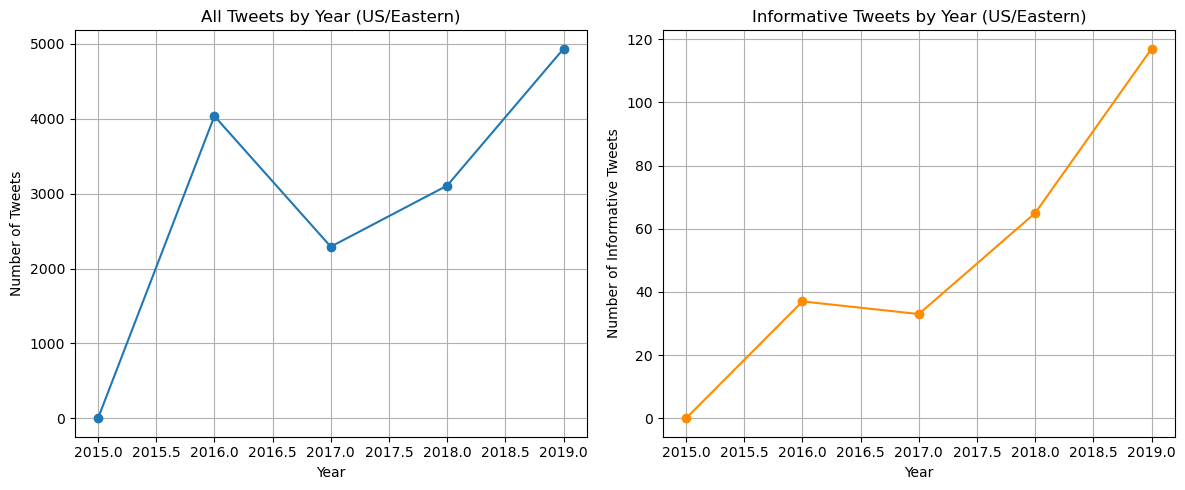

In [ ]:

# ===============================
# 1️⃣ Timezone handling (UTC -> US/Eastern)
# ===============================

df_matched['event_minute'] = pd.to_datetime(df_matched['event_minute'], utc=True)
df_matched['event_minute_est'] = df_matched['event_minute'].dt.tz_convert('US/Eastern')

df_matched['year_est'] = df_matched['event_minute_est'].dt.year


# ===============================
# 2️⃣ Informative flag
# ===============================

if 'is_informative' in df_matched.columns:
    df_matched['is_informative_flag'] = (
        df_matched['is_informative']
        .astype(str)
        .str.lower()
        .isin(['1','true','t','yes','y'])
        .astype(int)
    )
else:
    df_matched['is_informative_flag'] = (
        df_matched['matched_tickers']
        .astype(str)
        .str.contains(r'[A-Za-z0-9]', na=False)
        .astype(int)
    )

df_all = df_matched.copy()
df_info = df_matched[df_matched['is_informative_flag'] == 1].copy()


# ===============================
# 3️⃣ Yearly counts
# ===============================

year_counts_all = df_all['year_est'].value_counts().sort_index()
year_counts_info = df_info['year_est'].value_counts().sort_index()


all_years = sorted(set(year_counts_all.index).union(set(year_counts_info.index)))
year_counts_all = year_counts_all.reindex(all_years, fill_value=0)
year_counts_info = year_counts_info.reindex(all_years, fill_value=0)


# ===============================
# 4️⃣ Plot side-by-side
# ===============================

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Left: All Tweets
axes[0].plot(year_counts_all.index, year_counts_all.values, marker='o')
axes[0].set_title("All Tweets by Year (US/Eastern)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of Tweets")
axes[0].grid(True)

# Right: Informative Tweets
axes[1].plot(year_counts_info.index, year_counts_info.values, marker='o', color='darkorange')
axes[1].set_title("Informative Tweets by Year (US/Eastern)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of Informative Tweets")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 3-Time distribution by industry

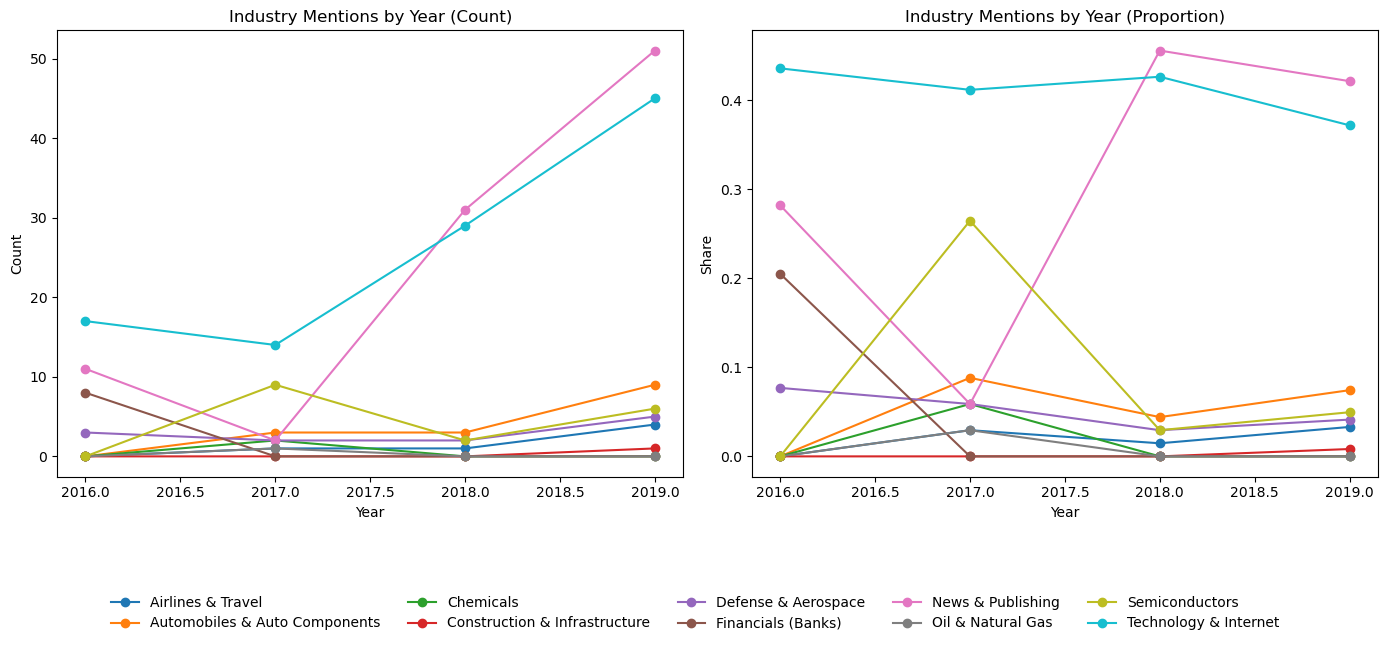

In [ ]:
df_matched['event_minute'] = pd.to_datetime(df_matched['event_minute'], utc=True)
df_matched['event_minute_est'] = df_matched['event_minute'].dt.tz_convert('US/Eastern')
df_matched['year_est'] = df_matched['event_minute_est'].dt.year

def parse_list(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return []
    elif isinstance(x, list):
        return x
    else:
        return []
df_matched['industry_list'] = df_matched['matched_industries'].apply(parse_list)
df_industry = df_matched[df_matched['industry_list'].str.len() > 0].copy()
df_industry = df_industry.explode('industry_list')
industry_year_counts = (
    df_industry
    .groupby(['year_est','industry_list'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)


industry_year_prop = industry_year_counts.div(
    industry_year_counts.sum(axis=1), axis=0
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

# Plot count data
for col in industry_year_counts.columns:
    axes[0].plot(
        industry_year_counts.index,
        industry_year_counts[col],
        marker='o',
        label=col
    )

# Plot proportion data
for col in industry_year_prop.columns:
    axes[1].plot(
        industry_year_prop.index,
        industry_year_prop[col],
        marker='o',
        label=col
    )

# Titles
axes[0].set_title("Industry Mentions by Year (Count)")
axes[1].set_title("Industry Mentions by Year (Proportion)")

# Axis labels
axes[0].set_xlabel("Year")
axes[1].set_xlabel("Year")

axes[0].set_ylabel("Count")
axes[1].set_ylabel("Share")

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    ncol=5,
    bbox_to_anchor=(0.5, -0.08),
    frameon=False
)

plt.tight_layout(rect=[0, 0.10, 1, 1])
plt.show()